## NX-414: Brain-like computation and intelligence
Notebook prepared by Alessandro Marin Vargas

# Week 6 - Mini project (Predicting neural activity)

The objectives of the mini project are:
- Learn how to predict neural activity using linear regression from images and from neural network layers.
- Quantify the goodness of the model
- Compare the results across the network layers and between trained/random neural network
- Predict the neural activity using a neural network in a data-driven approach

Specifically, here you will use the data from the following [paper](https://www.jneurosci.org/content/jneuro/35/39/13402.full.pdf). The behavioral experiment consisted in showing to non-human primates some images while recording the neural activity with multielectrode arrays from the inferior temporal (IT) cortex. In the data we provided you, the neural activity and the images are already pre-processed and you will have available the images and the corresponding average firing rate (between 70 and 170 ms) per each neuron.

### Deadline for Mini-Project Submission: May 7, 2025

You are required to submit your mini-projects by midnight on 07/05/25. Please upload a .zip file to Moodle containing your code, along with the following specific components:

- One-Page Report (Report.pdf): This should detail your investigative process and include:
    - A comparison table of models. This should cover linear regression from stimuli, both trained and random task-driven models, data-driven models, and your best-performing model.
    - A figure illustrating the variation in neural prediction across different layers of a task-driven model.
    - Your exploration to develop the most effective model at predicting IT neural activity
- Example Script/Notebook: Please provide a script (test.py) or a notebook (test.ipynb) demonstrating how your best model performs on the validation set. This should serve as an example of the model's usage.

In [1]:
import sys
!{sys.executable} -m pip install gdown h5py

You should consider upgrading via the '/home/vvoigt/Documents/NX/NX-414-Project/venv/bin/python -m pip install --upgrade pip' command.


In [2]:
### Utils
import h5py
import os

import matplotlib.pyplot as plt
import numpy as np


def load_it_data(path_to_data):
    """ Load IT data

    Args:
        path_to_data (str): Path to the data

    Returns:
        np.array (x6): Stimulus train/val/test; objects list train/val/test; spikes train/val
    """

    datafile = h5py.File(os.path.join(path_to_data,'IT_data.h5'), 'r')

    stimulus_train = datafile['stimulus_train'][()]
    spikes_train = datafile['spikes_train'][()]
    objects_train = datafile['object_train'][()]
    
    stimulus_val = datafile['stimulus_val'][()]
    spikes_val = datafile['spikes_val'][()]
    objects_val = datafile['object_val'][()]
    
    stimulus_test = datafile['stimulus_test'][()]
    objects_test = datafile['object_test'][()]

    ### Decode back object type to latin
    objects_train = [obj_tmp.decode("latin-1") for obj_tmp in objects_train]
    objects_val = [obj_tmp.decode("latin-1") for obj_tmp in objects_val]
    objects_test = [obj_tmp.decode("latin-1") for obj_tmp in objects_test]

    return stimulus_train, stimulus_val, stimulus_test, objects_train, objects_val, objects_test, spikes_train, spikes_val


def visualize_img(stimulus,objects,stim_idx):
    """Visualize image given the stimulus and corresponding index and the object name.

    Args:
        stimulus (array of float): Stimulus containing all the images
        objects (list of str): Object list containing all the names
        stim_idx (int): Index of the stimulus to plot
    """    
    normalize_mean=[0.485, 0.456, 0.406]
    normalize_std=[0.229, 0.224, 0.225]

    img_tmp = np.transpose(stimulus[stim_idx],[1,2,0])

    ### Go back from normalization
    img_tmp = (img_tmp*normalize_std + normalize_mean) * 255

    plt.figure()
    plt.imshow(img_tmp.astype(np.uint8),cmap='gray')
    plt.title(str(objects[stim_idx]))
    plt.show()
    return


In [3]:
#from utils import load_it_data, visualize_img
import matplotlib.pyplot as plt
import numpy as np
import gdown
url = "https://drive.google.com/file/d/1s6caFNRpyR9m7ZM6XEv_e8mcXT3_PnHS/view?usp=share_link"
output = "IT_data.h5"
gdown.download(url, output, quiet=False, fuzzy=True)


Downloading...
From (original): https://drive.google.com/uc?id=1s6caFNRpyR9m7ZM6XEv_e8mcXT3_PnHS
From (redirected): https://drive.google.com/uc?id=1s6caFNRpyR9m7ZM6XEv_e8mcXT3_PnHS&confirm=t&uuid=82935efc-18cd-4e93-8cf2-d8403a270692
To: /home/vvoigt/IT_data.h5
100%|████████████████████████████████████████████████████████████████████████████| 384M/384M [00:02<00:00, 147MB/s]


'IT_data.h5'

### Load the data

In [4]:
path_to_data = '' ## Insert the folder where the data is, if you download in the same folder as this notebook then leave it blank

stimulus_train, stimulus_val, stimulus_test, objects_train, objects_val, objects_test, spikes_train, spikes_val = load_it_data(path_to_data)


In [5]:
n_stimulus, n_channels, img_size, _ = stimulus_train.shape
_, n_neurons = spikes_train.shape
print('The train dataset contains {} stimuli and {} IT neurons'.format(n_stimulus,n_neurons))
print('Each stimulus have {} channgels (RGB)'.format(n_channels))
print('The size of the image is {}x{}'.format(img_size,img_size))

The train dataset contains 2592 stimuli and 168 IT neurons
Each stimulus have 3 channgels (RGB)
The size of the image is 224x224


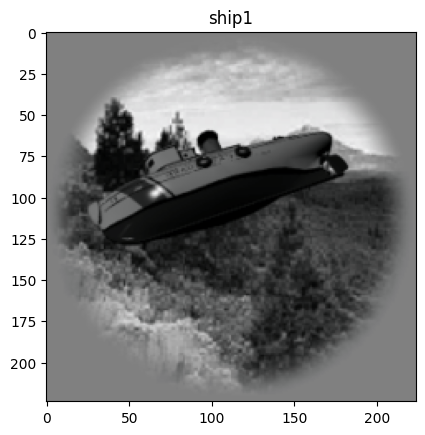

In [6]:
stim_idx = 11

visualize_img(stimulus_train,objects_train,stim_idx)

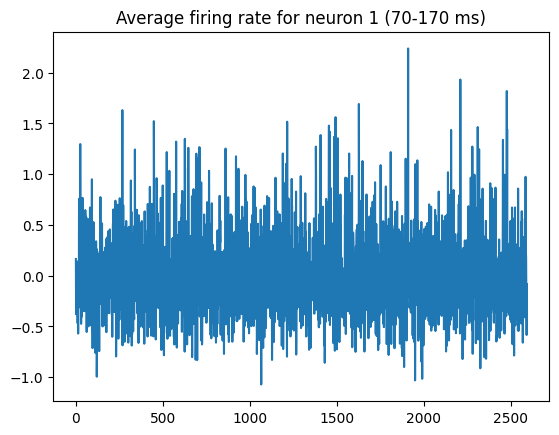

In [7]:
neuron_idx = 1

plt.figure()
plt.title('Average firing rate for neuron {} (70-170 ms)'.format(neuron_idx))
plt.plot(spikes_train[:,neuron_idx])

In [ ]:
stimulus_train[3,1]

array([[0.2051822, 0.2051822, 0.2051822, ..., 0.2051822, 0.2051822,
        0.2051822],
       [0.2051822, 0.2051822, 0.2051822, ..., 0.2051822, 0.2051822,
        0.2051822],
       [0.2051822, 0.2051822, 0.2051822, ..., 0.2051822, 0.2051822,
        0.2051822],
       ...,
       [0.2051822, 0.2051822, 0.2051822, ..., 0.2051822, 0.2051822,
        0.2051822],
       [0.2051822, 0.2051822, 0.2051822, ..., 0.2051822, 0.2051822,
        0.2051822],
       [0.2051822, 0.2051822, 0.2051822, ..., 0.2051822, 0.2051822,
        0.2051822]], dtype=float32)

: 

## Part 1: Predict the neural activity from pixels

##### Develop a linear regression model that predict the neural activity from pixels.
You can try out different types of linear regression (ridge, least-square regression)

In [9]:
#### Here your code
from sklearn.linear_model import Ridge
import numpy as np
from sklearn.preprocessing import StandardScaler

X_train = stimulus_train.reshape(2592, -1)
y_train = spikes_train

# Normalize data
scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)

# Train Ridge regression model
alpha = 1.0
ridge = Ridge(alpha=alpha)
ridge.fit(X_train, y_train)

: 

: 

##### Evaluate your prediction (Check both the correlation and explained variance for each neuron). Plot the distribution for the explained variance across neurons.

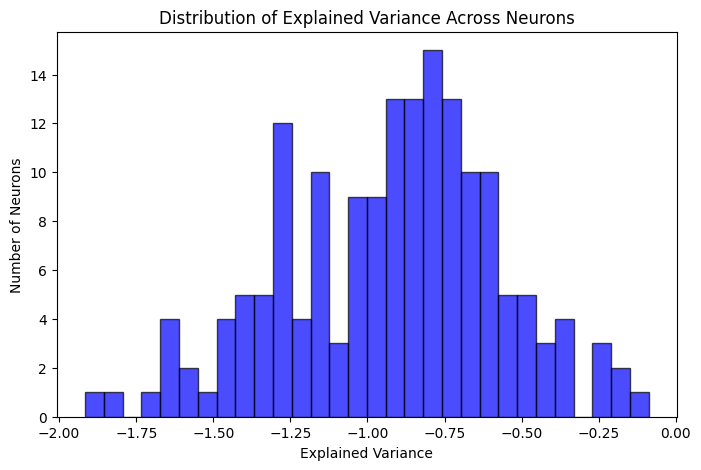

Mean Explained Variance: -0.9214
Mean Correlation: 0.1638


In [ ]:
#### Here your code
import scipy.stats
from sklearn.metrics import explained_variance_score

# Preprocess test data
X_val = stimulus_val.reshape(288, -1)
X_val = scaler_X.transform(X_val)
y_val = spikes_val

# Predict on test set
y_pred = ridge.predict(X_val)

# Compute explained variance for each neuron
explained_variance = explained_variance_score(y_val, y_pred, multioutput='raw_values')

# Compute correlation per neuron
correlations = np.array([scipy.stats.pearsonr(y_val[:, i], y_pred[:, i])[0] for i in range(y_val.shape[1])])

# Plot the distribution of explained variance
plt.figure(figsize=(8, 5))
plt.hist(explained_variance, bins=30, alpha=0.7, color='b', edgecolor='black')
plt.xlabel("Explained Variance")
plt.ylabel("Number of Neurons")
plt.title("Distribution of Explained Variance Across Neurons")
plt.show()

# Print summary statistics
print(f"Mean Explained Variance: {np.mean(explained_variance):.4f}")
print(f"Mean Correlation: {np.mean(correlations):.4f}")

##### Predicting from pixels is very hard and the model is likely to overfit. An image is very high-dimensional, try to retain the corresponding 1000 PCs and use them to predict the neural activity. 

In [ ]:
#### Here your code
from sklearn.decomposition import PCA

X_train = stimulus_train.reshape(2592, -1)
X_val = stimulus_val.reshape(288, -1)

scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_val = scaler_X.transform(X_val)

# Apply PCA to retain 1000 principal components
n_components = 1000
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)

# Train Ridge regression
y_train = spikes_train
y_val = spikes_val

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_pca, y_train)

# Predict on test set
y_pred = ridge.predict(X_val_pca)

# Compute explained variance for each neuron
explained_variance = explained_variance_score(y_val, y_pred, multioutput='raw_values')

# Compute correlation per neuron
correlations = np.array([scipy.stats.pearsonr(y_val[:, i], y_pred[:, i])[0] for i in range(y_val.shape[1])])

# Plot the distribution of explained variance
plt.figure(figsize=(8, 5))
plt.hist(explained_variance, bins=30, alpha=0.7, color='b', edgecolor='black')
plt.xlabel("Explained Variance")
plt.ylabel("Number of Neurons")
plt.title("Distribution of Explained Variance Across Neurons")
plt.show()

# Print summary statistics
print(f"Mean Explained Variance: {np.mean(explained_variance):.4f}")
print(f"Mean Correlation: {np.mean(correlations):.4f}")

##### Can we improve the prediction? Using the ridge regression, find the best parameter with cross-fold validation (remember to split the data keeping the same distribution of classes between the train and validation set). Does it get better?

In [ ]:
#### Here your code
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.linear_model import Ridge
import numpy as np
import matplotlib.pyplot as plt


# Define range of alpha values to test
alphas = np.logspace(-2, 2, 20)

# Set up 5-fold cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform Grid Search with Cross-Validation
ridge_cv = GridSearchCV(Ridge(), param_grid={'alpha': alphas}, cv=cv, scoring='explained_variance', n_jobs=-1)
ridge_cv.fit(X_train_pca, y_train)

# Get the best alpha
best_alpha = ridge_cv.best_params_['alpha']
print(f"Best alpha: {best_alpha:.4f}")

# Train Ridge regression using the best alpha
ridge_best = Ridge(alpha=best_alpha)
ridge_best.fit(X_train_pca, y_train)

# Predict on validation set
y_pred_best = ridge_best.predict(X_val_pca)

# Compute explained variance for each neuron
explained_variance_best = explained_variance_score(y_val, y_pred_best, multioutput='raw_values')

# Compute correlation per neuron
correlations_best = np.array([scipy.stats.pearsonr(y_val[:, i], y_pred_best[:, i])[0] for i in range(y_val.shape[1])])

# Plot the improved explained variance distribution
plt.figure(figsize=(8, 5))
plt.hist(explained_variance_best, bins=30, alpha=0.7, color='g', edgecolor='black')
plt.xlabel("Explained Variance")
plt.ylabel("Number of Neurons")
plt.title("Improved Distribution of Explained Variance Across Neurons")
plt.show()

# Print comparison of performance
print(f"Mean Explained Variance (Before Tuning): {np.mean(explained_variance):.4f}")
print(f"Mean Explained Variance (After Tuning): {np.mean(explained_variance_best):.4f}")
print(f"Mean Correlation (Before Tuning): {np.mean(correlations):.4f}")
print(f"Mean Correlation (After Tuning): {np.mean(correlations_best):.4f}")

### Part 2: Predict the neural activity with the task-driven modeling approach

As you have seen in the class, the underlying hypothesis of task-driven modeling is that training the network to perform a relevant behavioral task makes the network to develop representations that resemble the ones of the biological brain. Let's test this hypothesis by loading a pre-trained ResNet50 model and use the activations of each layer to predict the neural activity. Follow these steps:

- Give as input to the network the stimuli and extract the corresponding activations of the following layers ['conv1','layer1','layer2','layer3','layer4','avgpool']
- Compute the 1000 PCs for each layer activation. (Careful that you don't want to store all activations together at the same time because it won't fit in the memory. Therefore, compute the activations and corresponding PCs for each layer and store only the computed PCs).
- Use the PCs of each layer to predict the neural activity using the linear regression models you developed before.
- Compute the goodness of fit using the correlation and explained variance metrics. Do you predict the neural activity better than before?
- Plot the distribution of explained variance with respect to the layer of the network (order them based on the depth). How does the neural activity changes across the model layers, can you make some statements about it?
- Compare the predictions that you obtained using one layer of the pretrained model and the one obtained using the same layer but from a randomly initialized model. Which network can better predict the neural activity and why?

In [ ]:
#### Here your code